In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)

from google.colab import files
uploaded = files.upload()

In [6]:
from google.colab import files
uploaded = files.upload()

Saving amazon.csv to amazon.csv


In [10]:
!ls -lh

total 4.0M
-rw-r--r-- 1 root root 2.0M Jun 23 23:14 amazon.csv
-rw-r--r-- 1 root root 2.0M Jun 23 23:13 archive.zip
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


In [11]:
!file amazon.csv

amazon.csv: Zip archive data, at least v4.5 to extract, compression method=deflate


In [15]:
!unzip -o archive.zip

Archive:  archive.zip
  inflating: amazon.csv              


In [16]:
import pandas as pd

df = pd.read_csv("amazon.csv")

print("Rows, Columns:", df.shape)

df.head()

Rows, Columns: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [17]:
df.columns.tolist()

['product_id',
 'product_name',
 'category',
 'discounted_price',
 'actual_price',
 'discount_percentage',
 'rating',
 'rating_count',
 'about_product',
 'user_id',
 'user_name',
 'review_id',
 'review_title',
 'review_content',
 'img_link',
 'product_link']

In [18]:
data = df.copy()

data['discounted_price'] = (
    data['discounted_price']
    .astype(str)
    .str.replace('₹','',regex=False)
    .str.replace(',','',regex=False)
)

data['actual_price'] = (
    data['actual_price']
    .astype(str)
    .str.replace('₹','',regex=False)
    .str.replace(',','',regex=False)
)

data['discount_percentage'] = (
    data['discount_percentage']
    .astype(str)
    .str.replace('%','',regex=False)
)

data['rating_count'] = (
    data['rating_count']
    .astype(str)
    .str.replace(',','',regex=False)
)

data['discounted_price'] = pd.to_numeric(data['discounted_price'], errors='coerce')
data['actual_price'] = pd.to_numeric(data['actual_price'], errors='coerce')
data['discount_percentage'] = pd.to_numeric(data['discount_percentage'], errors='coerce')
data['rating'] = pd.to_numeric(data['rating'], errors='coerce')
data['rating_count'] = pd.to_numeric(data['rating_count'], errors='coerce')

data = data.dropna()

print(data.shape)

(1462, 16)


In [19]:
data['main_category'] = data['category'].str.split('|').str[0]

data['discount_amount'] = (
    data['actual_price']
    - data['discounted_price']
)

data['estimated_revenue'] = (
    data['discounted_price']
    * data['rating_count']
)

data['estimated_discount_loss'] = (
    data['discount_amount']
    * data['rating_count']
)

data.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,main_category,discount_amount,estimated_revenue,estimated_discount_loss
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers&Accessories,700.0,9683331.0,16988300.0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories,150.0,8754806.0,6599100.0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories,1700.0,1577672.0,13477600.0
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Computers&Accessories,370.0,31045427.0,34914310.0
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Computers&Accessories,245.0,2603370.0,4141725.0


In [20]:
print("Total Products :", data['product_id'].nunique())
print("Total Categories :", data['main_category'].nunique())
print("Average Rating :", round(data['rating'].mean(),2))
print("Average Discount :", round(data['discount_percentage'].mean(),2))
print("Total Reviews :", int(data['rating_count'].sum()))
print("Estimated Revenue :", round(data['estimated_revenue'].sum()/10000000,2),"Crore")

Total Products : 1348
Total Categories : 9
Average Rating : 4.1
Average Discount : 47.67
Total Reviews : 26765385
Estimated Revenue : 7191.77 Crore


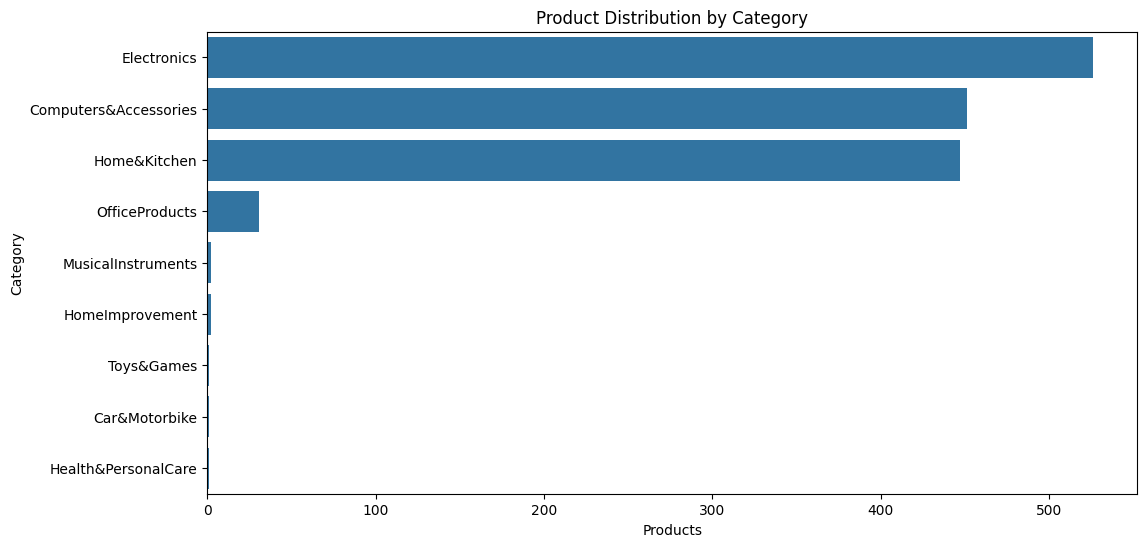

In [51]:
top_cat = data['main_category'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_cat.values,
    y=top_cat.index
)

plt.title("Product Distribution by Category")
plt.xlabel("Products")
plt.ylabel("Category")

plt.savefig("charts/chart_name.png", bbox_inches="tight", dpi=300)
plt.show()

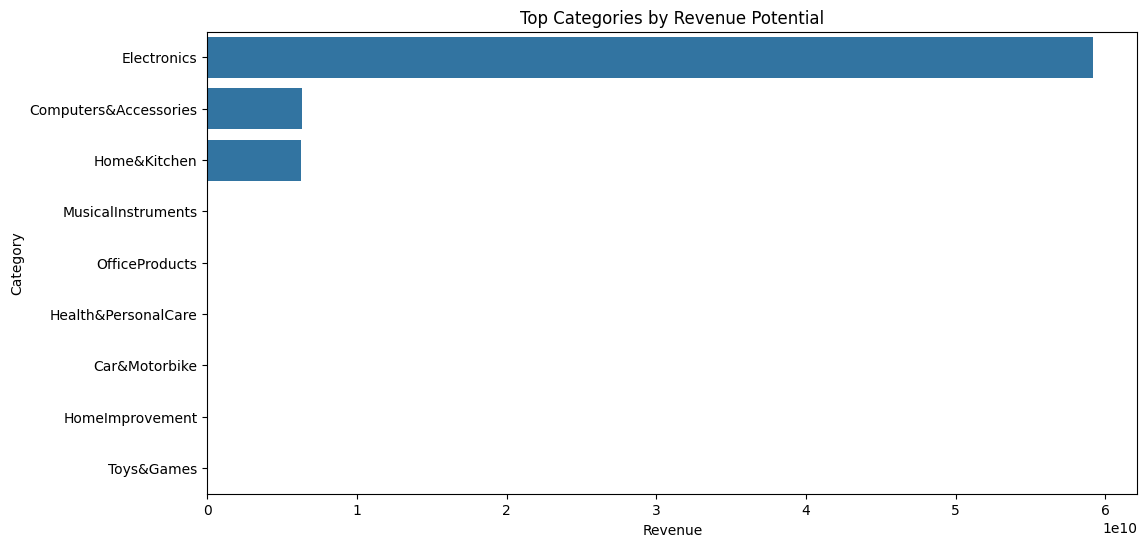

In [56]:
revenue_cat = (
    data.groupby('main_category')['estimated_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=revenue_cat.values,
    y=revenue_cat.index
)

plt.title("Top Categories by Revenue Potential")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()


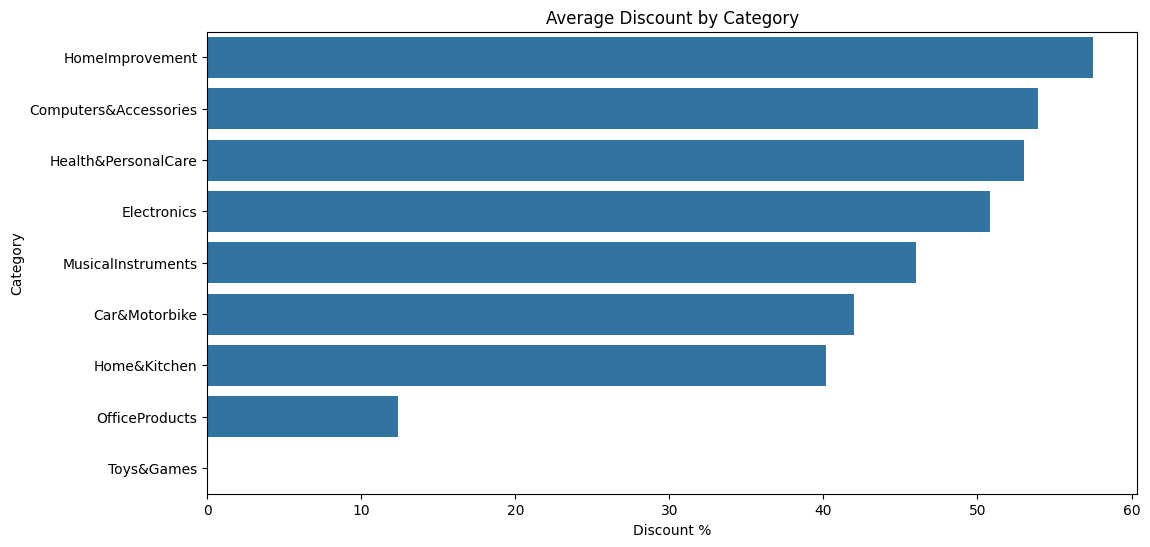

In [57]:
discount_cat = (
    data.groupby('main_category')['discount_percentage']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=discount_cat.values,
    y=discount_cat.index
)

plt.title("Average Discount by Category")
plt.xlabel("Discount %")
plt.ylabel("Category")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

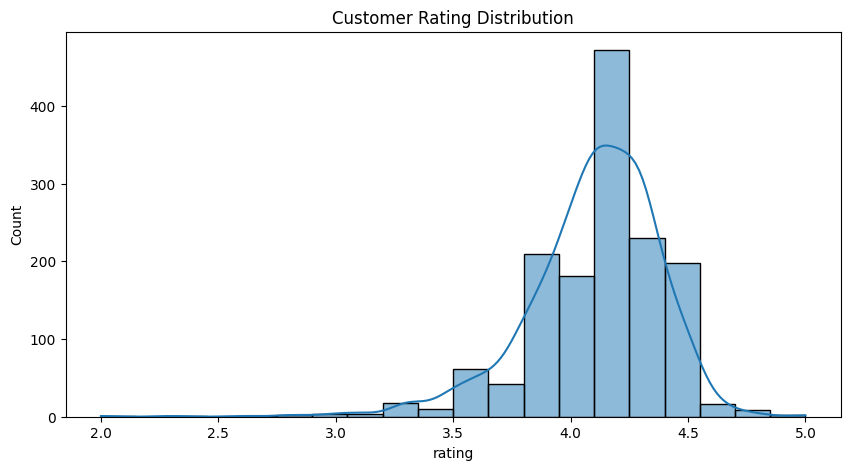

In [58]:
plt.figure(figsize=(10,5))

sns.histplot(
    data['rating'],
    bins=20,
    kde=True
)

plt.title("Customer Rating Distribution")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

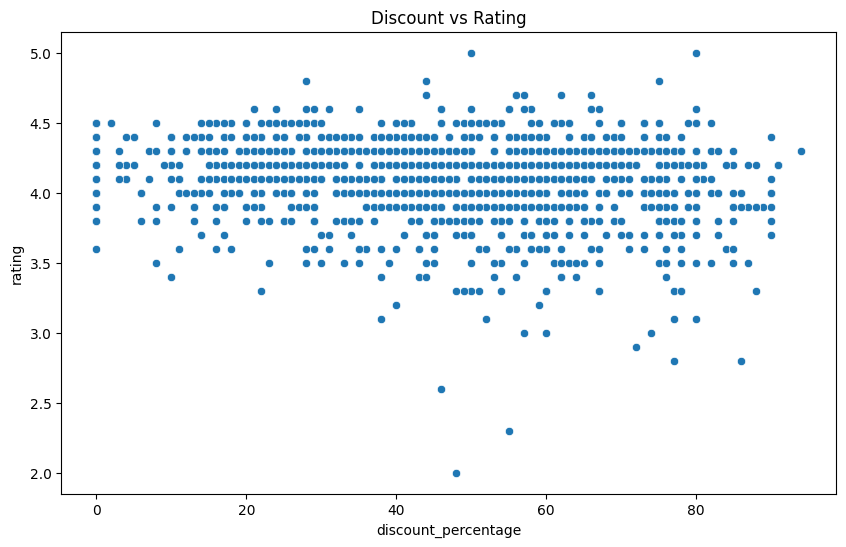

In [59]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x='discount_percentage',
    y='rating'
)

plt.title("Discount vs Rating")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

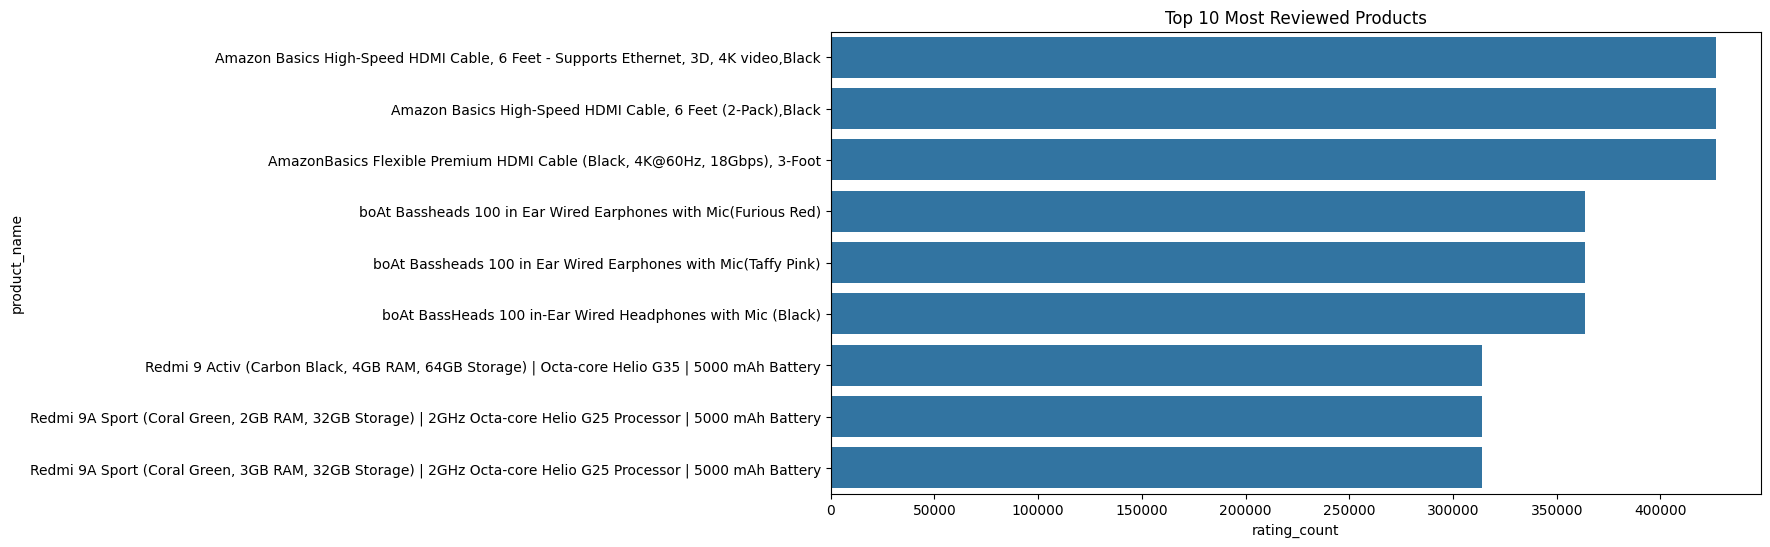

In [60]:
top_review = (
    data.sort_values(
        'rating_count',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x='rating_count',
    y='product_name',
    data=top_review
)

plt.title("Top 10 Most Reviewed Products")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

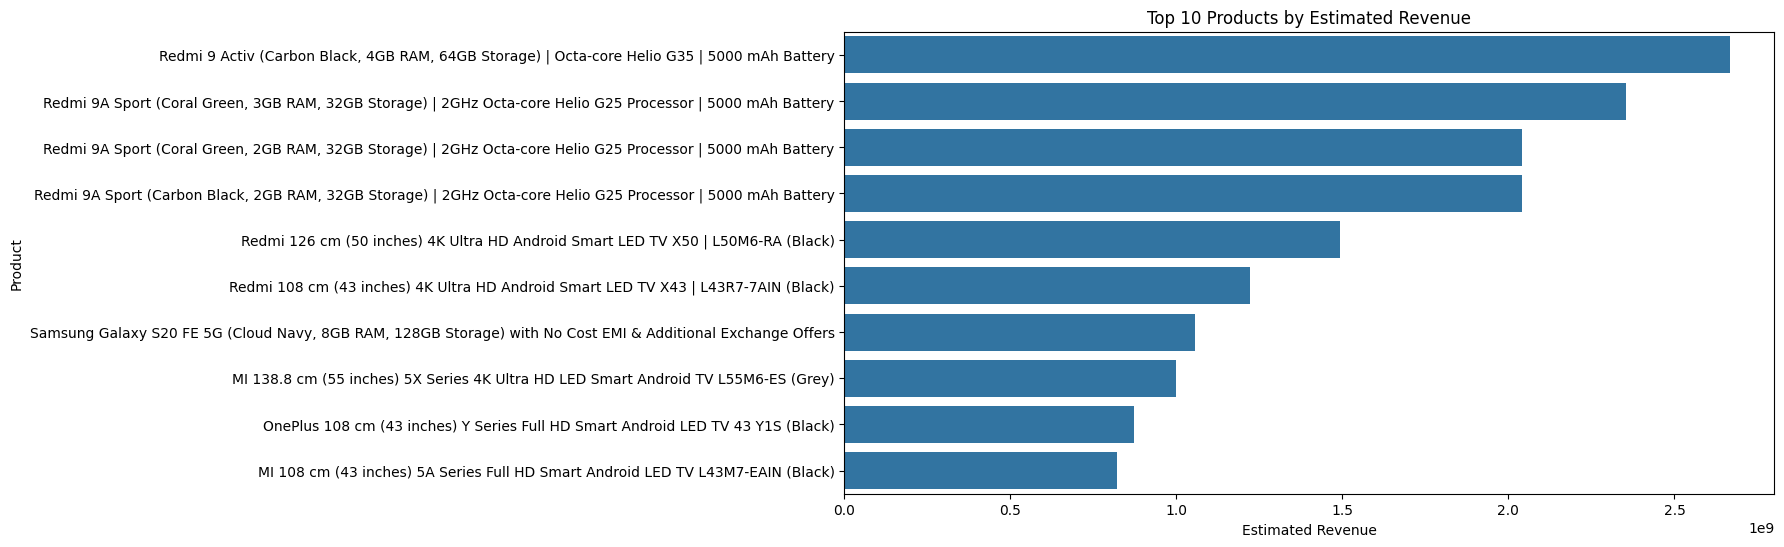

In [61]:
top_revenue_products = data.sort_values('estimated_revenue', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x='estimated_revenue',
    y='product_name',
    data=top_revenue_products
)

plt.title("Top 10 Products by Estimated Revenue")
plt.xlabel("Estimated Revenue")
plt.ylabel("Product")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

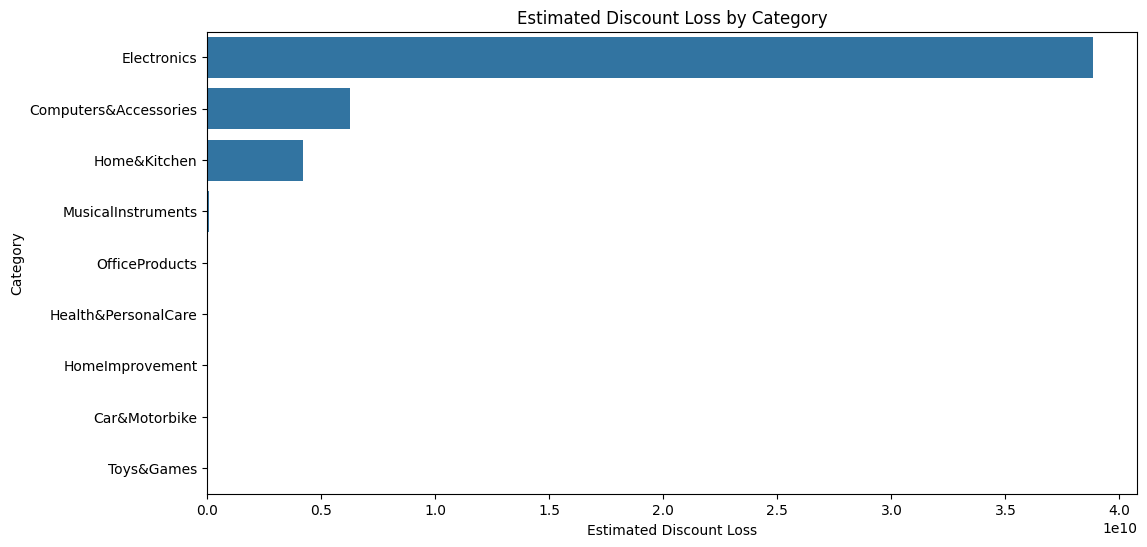

In [62]:
discount_loss_cat = (
    data.groupby('main_category')['estimated_discount_loss']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=discount_loss_cat.values,
    y=discount_loss_cat.index
)

plt.title("Estimated Discount Loss by Category")
plt.xlabel("Estimated Discount Loss")
plt.ylabel("Category")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

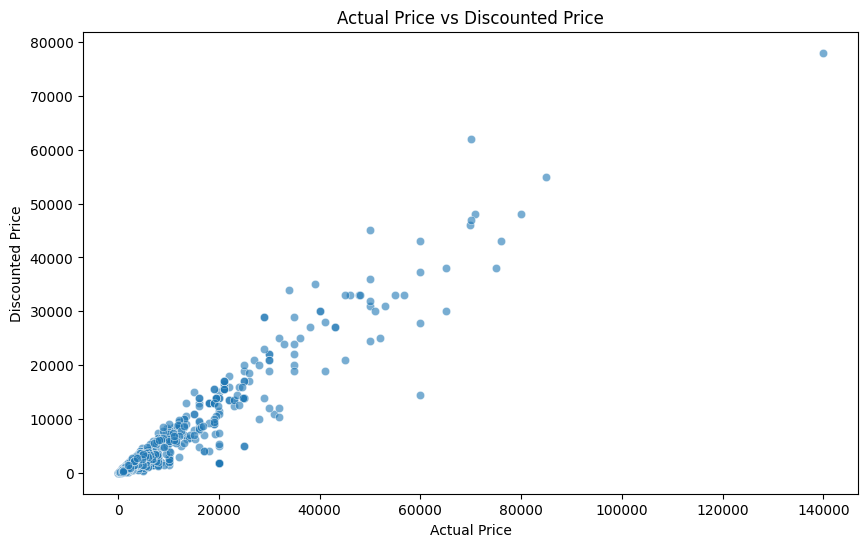

In [63]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=data,
    x='actual_price',
    y='discounted_price',
    alpha=0.6
)

plt.title("Actual Price vs Discounted Price")
plt.xlabel("Actual Price")
plt.ylabel("Discounted Price")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

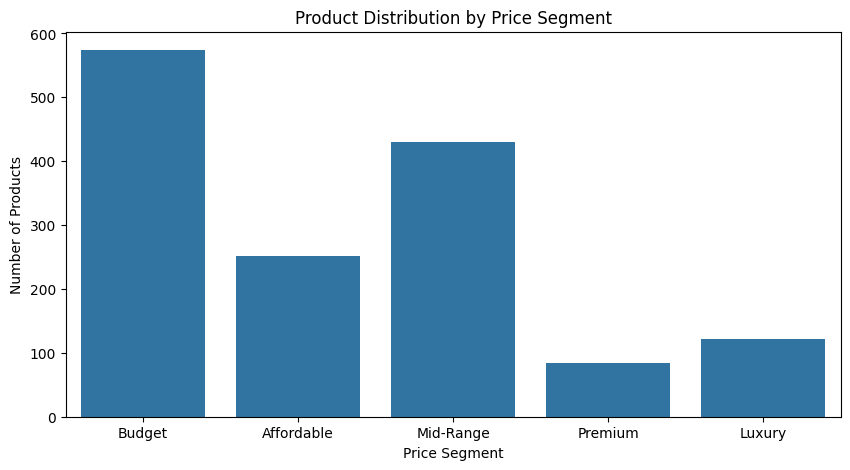

In [64]:
data['price_segment'] = pd.cut(
    data['discounted_price'],
    bins=[0, 500, 1000, 5000, 10000, data['discounted_price'].max()],
    labels=['Budget', 'Affordable', 'Mid-Range', 'Premium', 'Luxury']
)

price_segment_count = data['price_segment'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(
    x=price_segment_count.index,
    y=price_segment_count.values
)

plt.title("Product Distribution by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Products")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

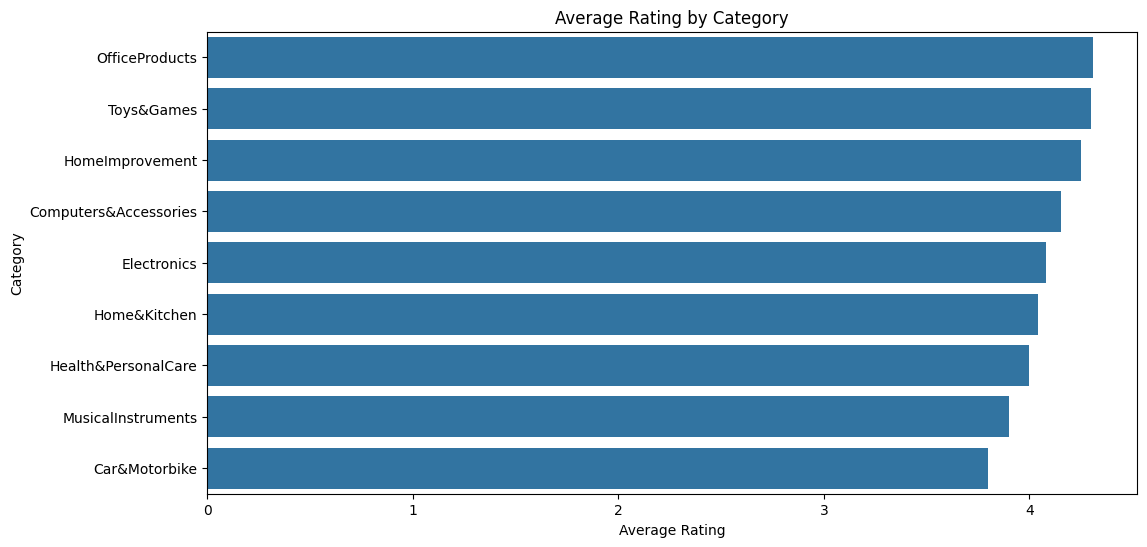

In [65]:
rating_cat = (
    data.groupby('main_category')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=rating_cat.values,
    y=rating_cat.index
)

plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

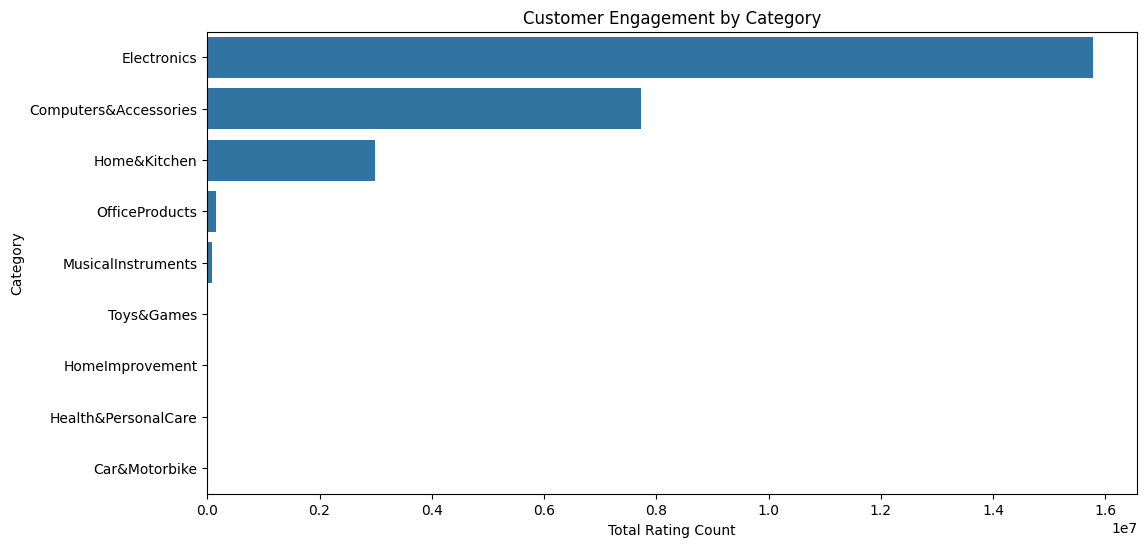

In [66]:
review_cat = (
    data.groupby('main_category')['rating_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=review_cat.values,
    y=review_cat.index
)

plt.title("Customer Engagement by Category")
plt.xlabel("Total Rating Count")
plt.ylabel("Category")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

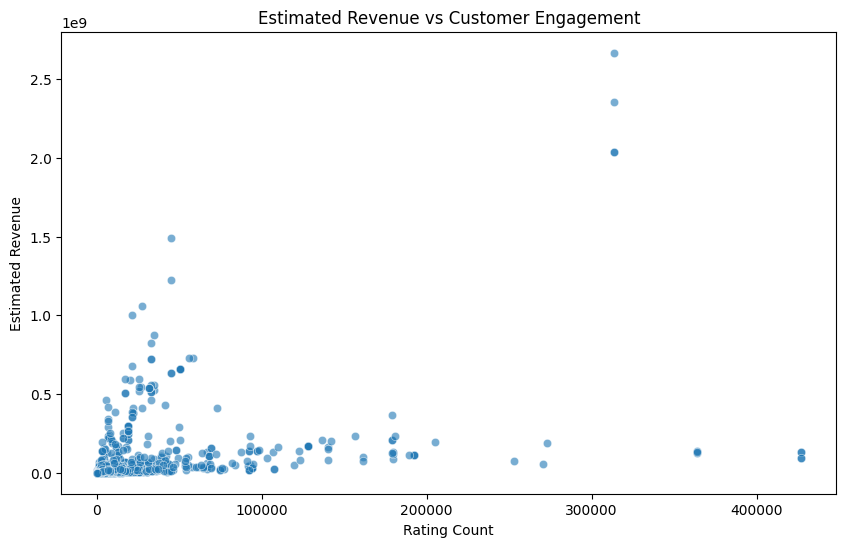

In [67]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=data,
    x='rating_count',
    y='estimated_revenue',
    alpha=0.6
)

plt.title("Estimated Revenue vs Customer Engagement")
plt.xlabel("Rating Count")
plt.ylabel("Estimated Revenue")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

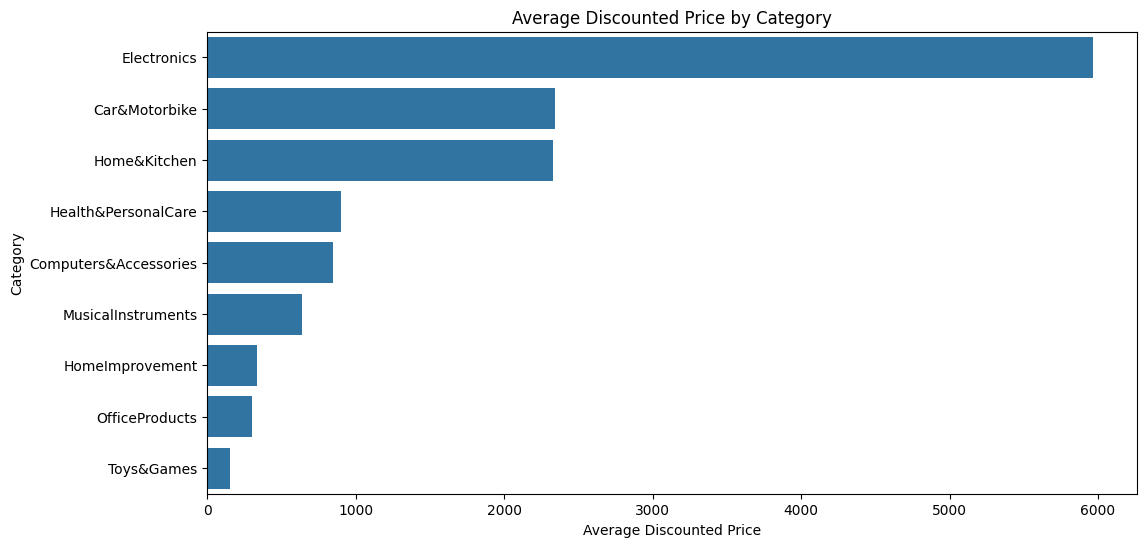

In [68]:
avg_price_cat = (
    data.groupby('main_category')['discounted_price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=avg_price_cat.values,
    y=avg_price_cat.index
)

plt.title("Average Discounted Price by Category")
plt.xlabel("Average Discounted Price")
plt.ylabel("Category")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

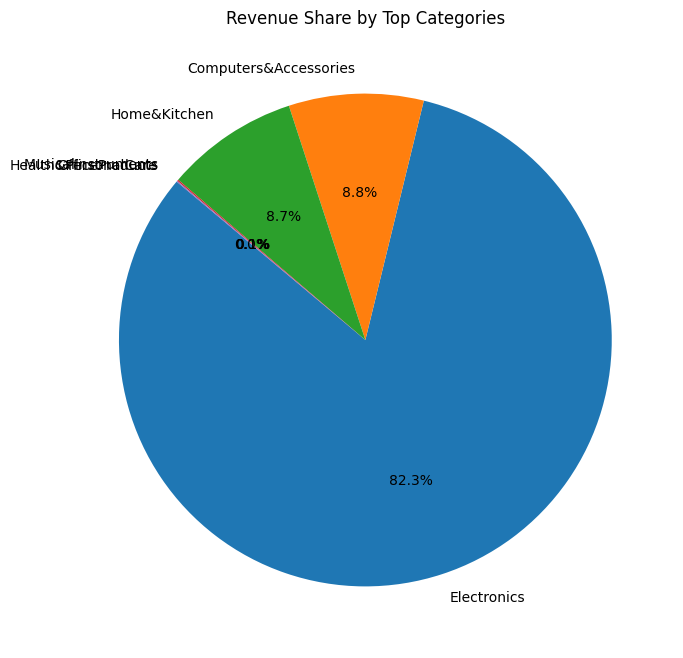

In [69]:
revenue_share = (
    data.groupby('main_category')['estimated_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(6)
)

plt.figure(figsize=(8,8))
plt.pie(
    revenue_share.values,
    labels=revenue_share.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Revenue Share by Top Categories")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

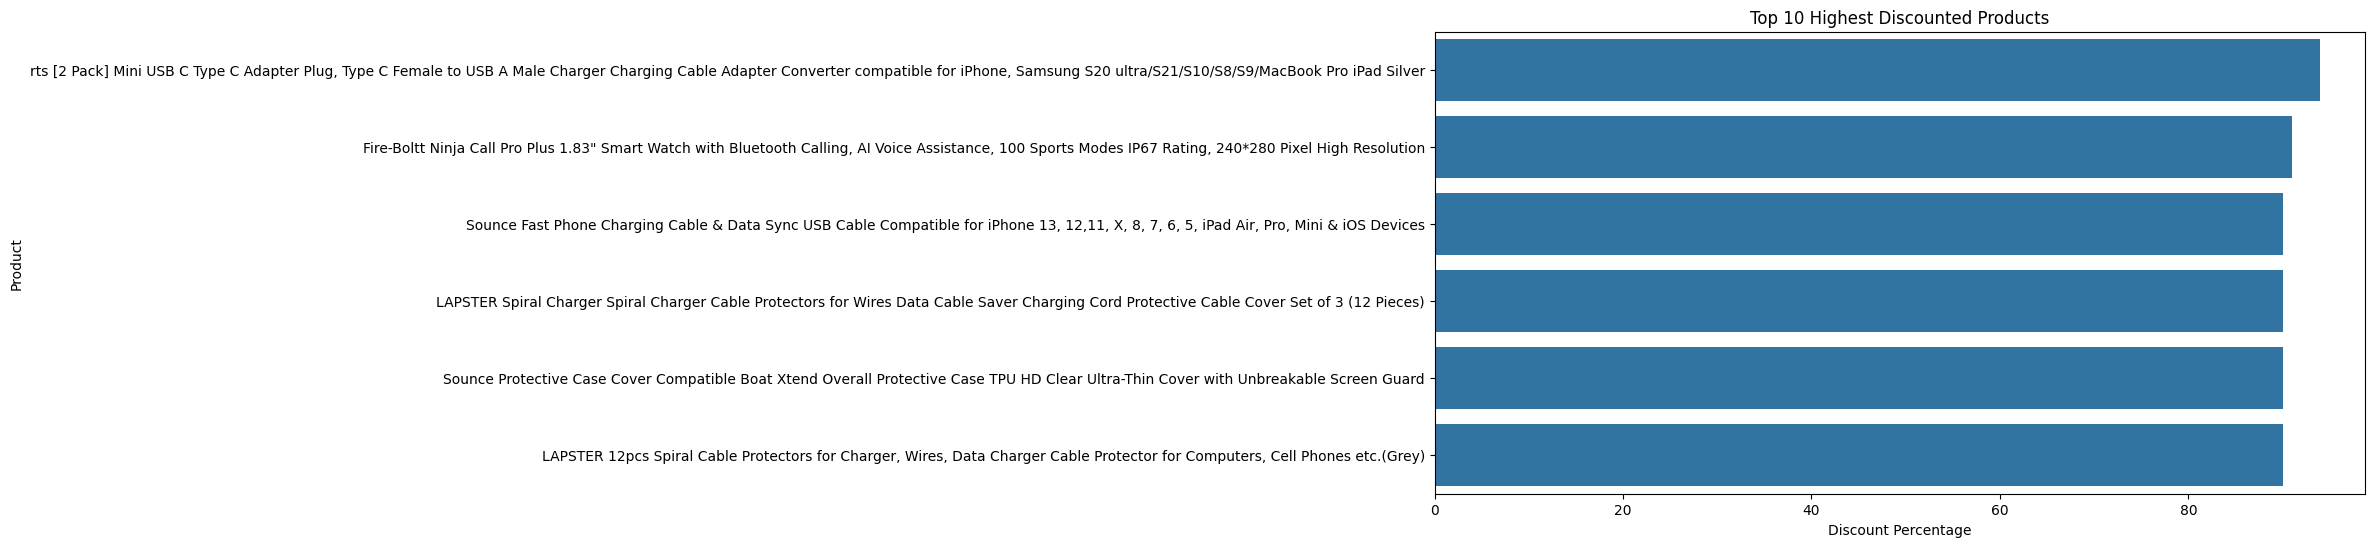

In [70]:
high_discount_products = data.sort_values('discount_percentage', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x='discount_percentage',
    y='product_name',
    data=high_discount_products
)

plt.title("Top 10 Highest Discounted Products")
plt.xlabel("Discount Percentage")
plt.ylabel("Product")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

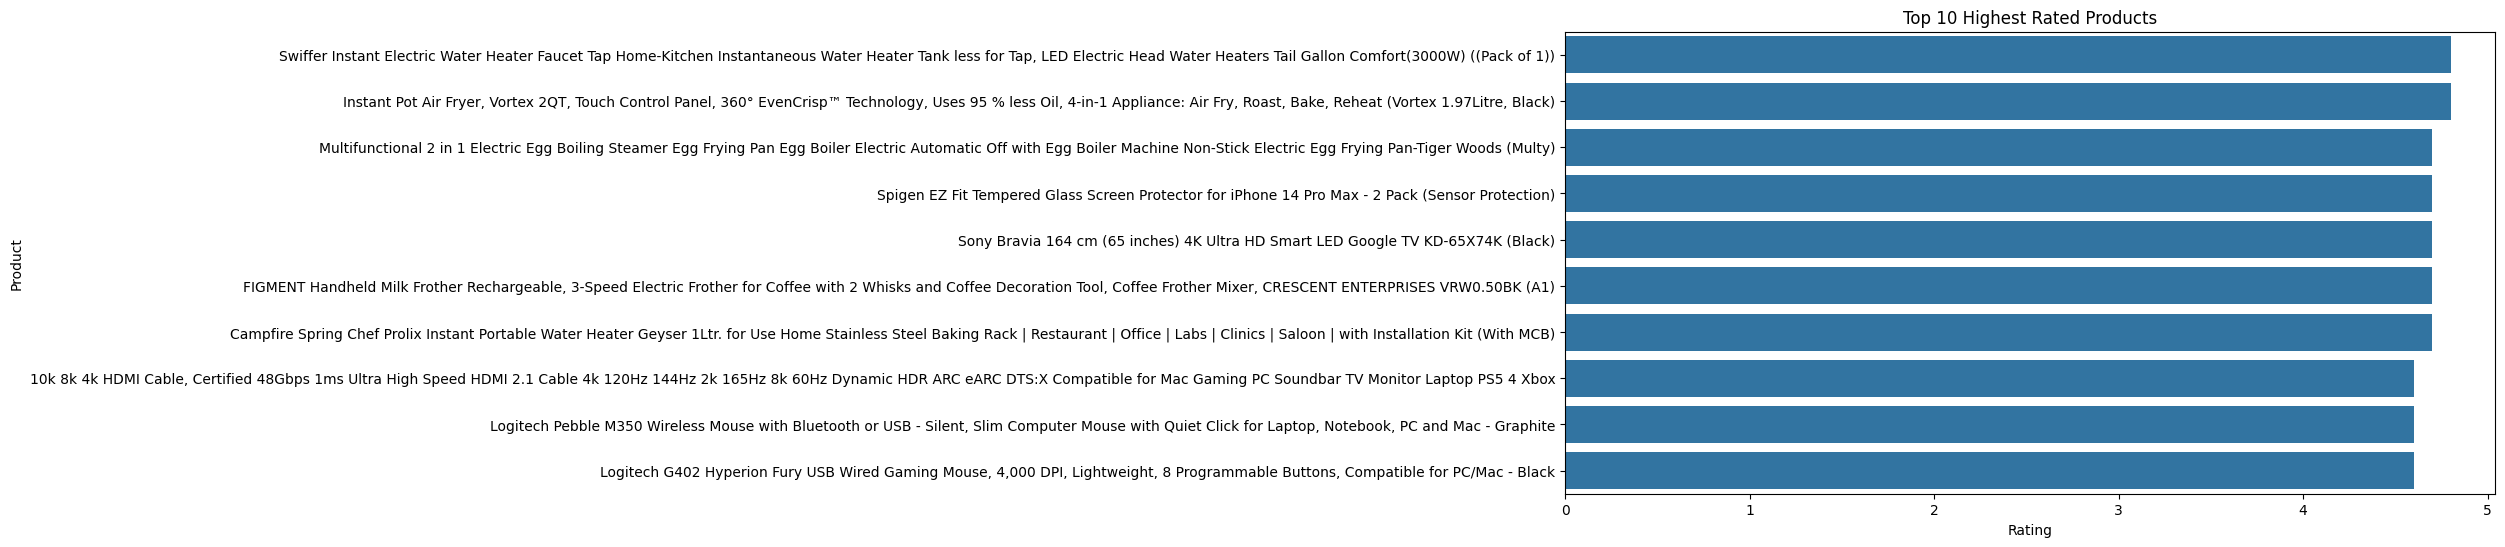

In [72]:
high_rated_products = data[data['rating_count'] > 1000].sort_values('rating', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x='rating',
    y='product_name',
    data=high_rated_products
)

plt.title("Top 10 Highest Rated Products")
plt.xlabel("Rating")
plt.ylabel("Product")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

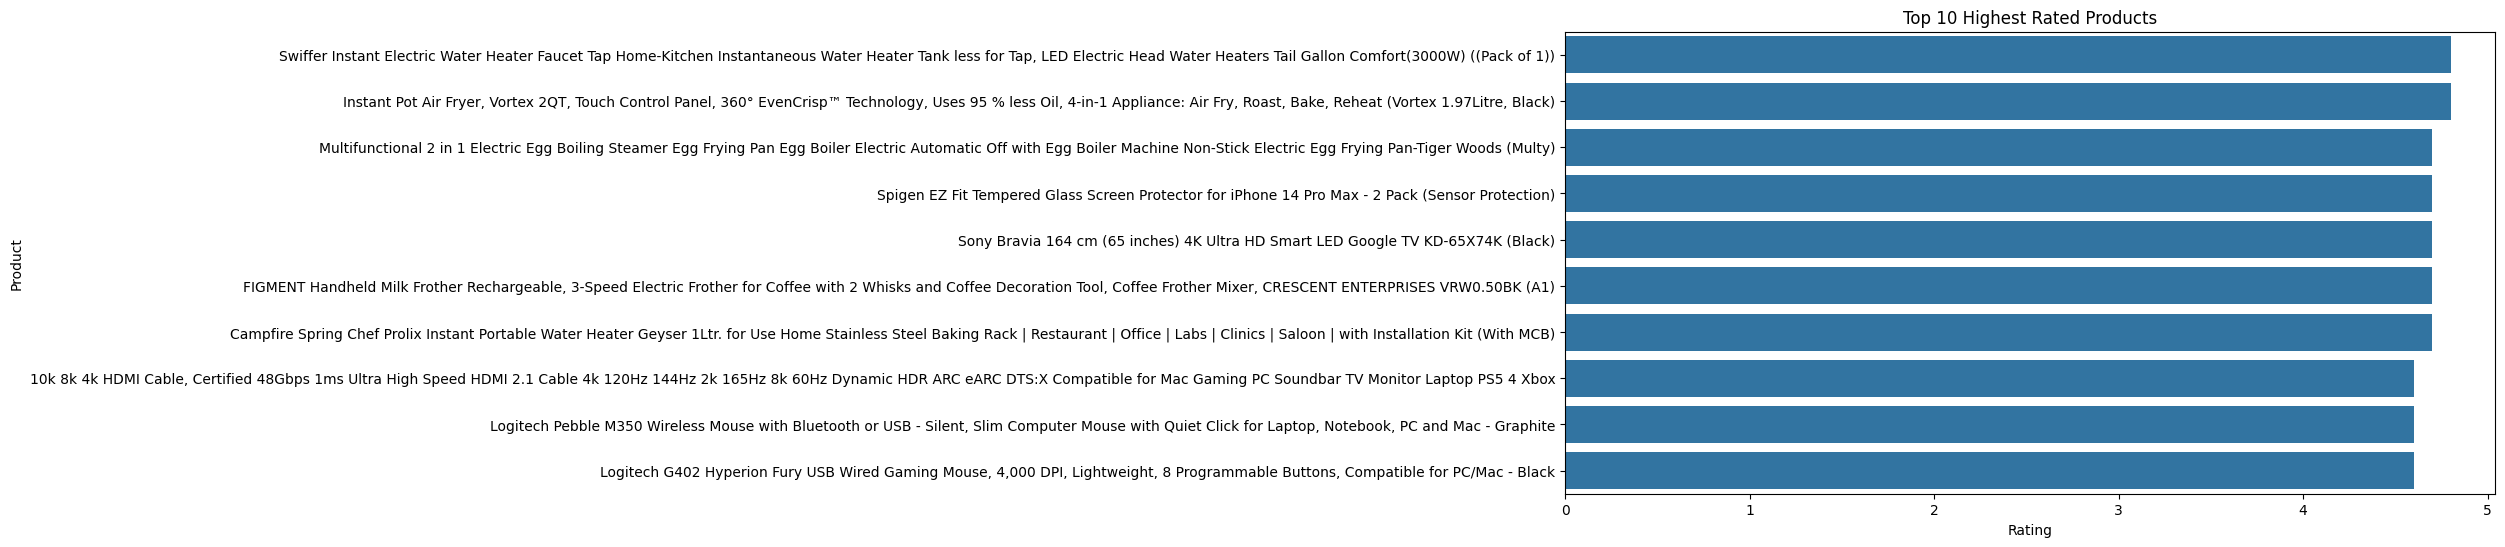

In [73]:
high_rated_products = data[data['rating_count'] > 1000].sort_values('rating', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x='rating',
    y='product_name',
    data=high_rated_products
)

plt.title("Top 10 Highest Rated Products")
plt.xlabel("Rating")
plt.ylabel("Product")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

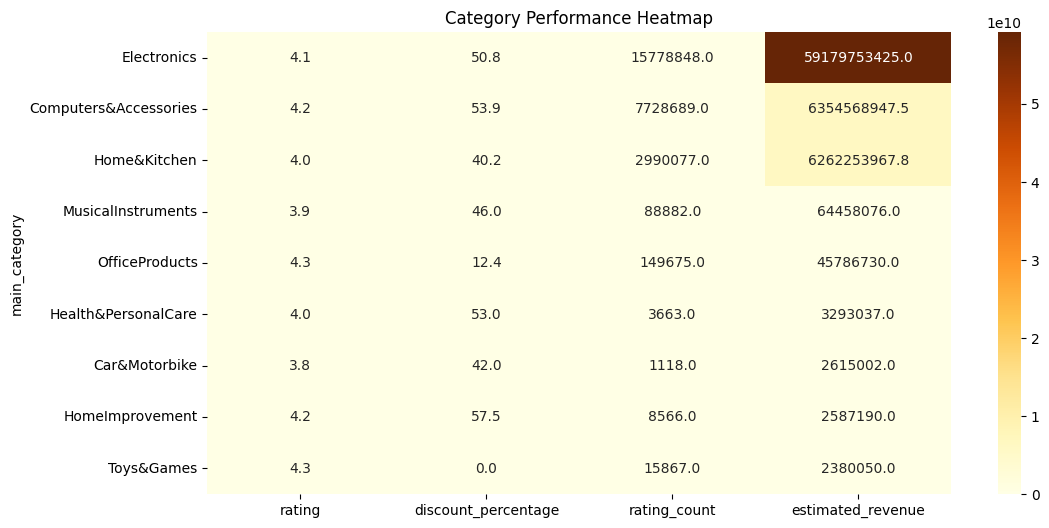

In [74]:
category_matrix = data.groupby('main_category').agg({
    'rating': 'mean',
    'discount_percentage': 'mean',
    'rating_count': 'sum',
    'estimated_revenue': 'sum'
}).sort_values('estimated_revenue', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.heatmap(
    category_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlOrBr'
)

plt.title("Category Performance Heatmap")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

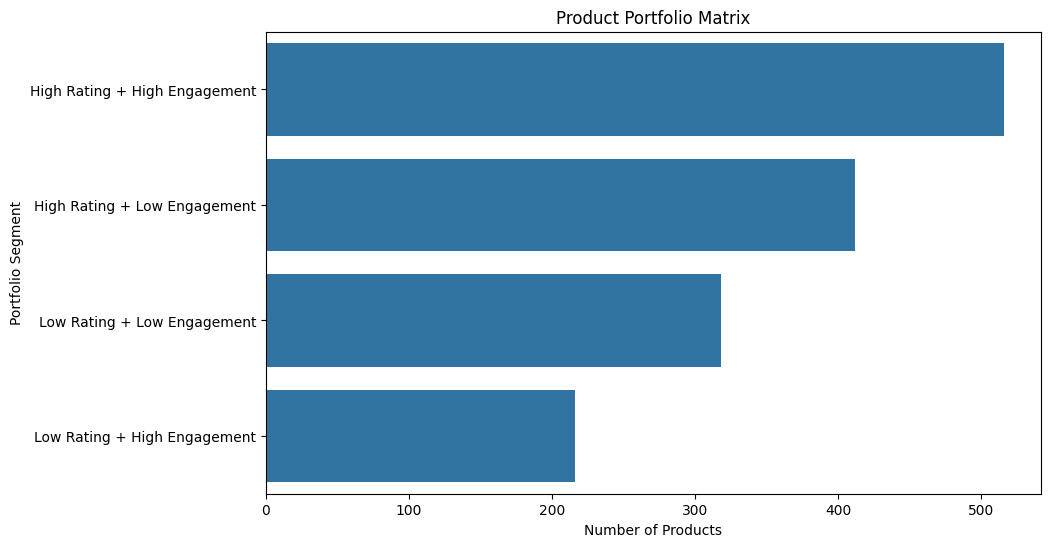

In [75]:
data['portfolio_segment'] = np.where(
    (data['rating'] >= data['rating'].median()) & (data['rating_count'] >= data['rating_count'].median()),
    'High Rating + High Engagement',
    np.where(
        (data['rating'] >= data['rating'].median()) & (data['rating_count'] < data['rating_count'].median()),
        'High Rating + Low Engagement',
        np.where(
            (data['rating'] < data['rating'].median()) & (data['rating_count'] >= data['rating_count'].median()),
            'Low Rating + High Engagement',
            'Low Rating + Low Engagement'
        )
    )
)

portfolio_count = data['portfolio_segment'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(
    x=portfolio_count.values,
    y=portfolio_count.index
)

plt.title("Product Portfolio Matrix")
plt.xlabel("Number of Products")
plt.ylabel("Portfolio Segment")

plt.savefig("charts/chart2_revenue_by_category.png", bbox_inches="tight", dpi=300)
plt.show()

In [41]:
print("""
FINAL BUSINESS INSIGHTS

1. Computer and electronics-related categories dominate the Amazon product catalogue.
2. Products with higher rating counts show stronger estimated revenue potential.
3. High discounts do not always guarantee better customer ratings.
4. Some categories show strong engagement but also high estimated discount loss.
5. High-rated and highly reviewed products should be prioritized for promotions.
6. Budget and mid-range products attract stronger customer engagement.
7. Revenue potential is concentrated in a few major categories.
8. Pricing and discount strategies need category-level optimization.
""")


FINAL BUSINESS INSIGHTS

1. Computer and electronics-related categories dominate the Amazon product catalogue.
2. Products with higher rating counts show stronger estimated revenue potential.
3. High discounts do not always guarantee better customer ratings.
4. Some categories show strong engagement but also high estimated discount loss.
5. High-rated and highly reviewed products should be prioritized for promotions.
6. Budget and mid-range products attract stronger customer engagement.
7. Revenue potential is concentrated in a few major categories.
8. Pricing and discount strategies need category-level optimization.



In [42]:
print("""
BUSINESS RECOMMENDATIONS

1. Promote high-rated products with strong customer engagement.
2. Optimize discounts to reduce unnecessary revenue leakage.
3. Focus marketing campaigns on categories with strong revenue potential.
4. Improve visibility of high-rated products with low engagement.
5. Use customer ratings and review counts to guide product strategy.
6. Create category-specific pricing strategies instead of applying uniform discounts.
7. Prioritize inventory planning for top-performing categories.
8. Monitor discount-heavy products to protect profitability.
""")


BUSINESS RECOMMENDATIONS

1. Promote high-rated products with strong customer engagement.
2. Optimize discounts to reduce unnecessary revenue leakage.
3. Focus marketing campaigns on categories with strong revenue potential.
4. Improve visibility of high-rated products with low engagement.
5. Use customer ratings and review counts to guide product strategy.
6. Create category-specific pricing strategies instead of applying uniform discounts.
7. Prioritize inventory planning for top-performing categories.
8. Monitor discount-heavy products to protect profitability.



In [43]:
data.to_csv("amazon_sales_cleaned_final.csv", index=False)

from google.colab import files
files.download("amazon_sales_cleaned_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
!ls

amazon.csv			archive.zip			 sample_data
amazon_sales_cleaned_final.csv	chart1_product_distribution.png


In [50]:
import os
os.makedirs("charts", exist_ok=True)

In [52]:
!ls charts

chart_name.png


In [54]:
from google.colab import files
files.download("charts/chart_name.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>